# **Spotify Mood Analysis**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/SpotifyFeatures.csv')

In [3]:
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [4]:
df.columns

Index(['genre', 'artist_name', 'track_name', 'track_id', 'popularity',
       'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence'],
      dtype='object')

# Create Mood Column

In [5]:
def mood(valence):
    if valence > 0.7:
        return "Happy"
    elif valence > 0.4:
        return "Calm"
    else:
        return "Sad"

df['Mood'] = df['valence'].apply(mood)

df[['track_name','valence','Mood']].head()

,track_name,valence,Mood
0,C'est beau de faire un Show,0.814,Happy
1,Perdu d'avance (par Gad Elmaleh),0.816,Happy
2,Don't Let Me Be Lonely Tonight,0.368,Sad
3,Dis-moi Monsieur Gordon Cooper,0.227,Sad
4,Ouverture,0.390,Sad


Now your dataset becomes mood-based 🎵

# Count Mood Songs

In [6]:
df['Mood'].value_counts()

,count
Mood,
Sad,104506
Calm,79639
Happy,48580


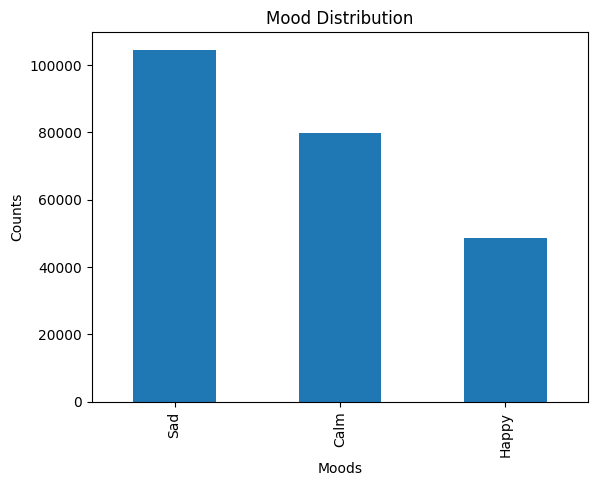

In [10]:
df['Mood'].value_counts().plot(kind='bar')

plt.xlabel("Moods")
plt.ylabel("Counts")
plt.title("Mood Distribution")
plt.show()

# Average Danceability by Mood

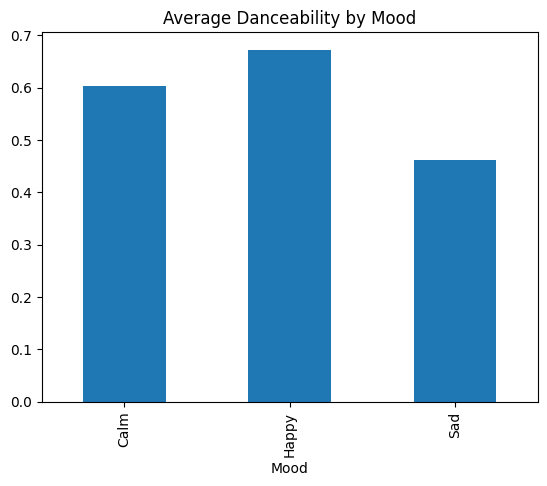

In [17]:
df.groupby('Mood')['danceability'].mean().plot(kind='bar')
plt.title("Average Danceability by Mood")
plt.show()

# Energy Distribution by Mood

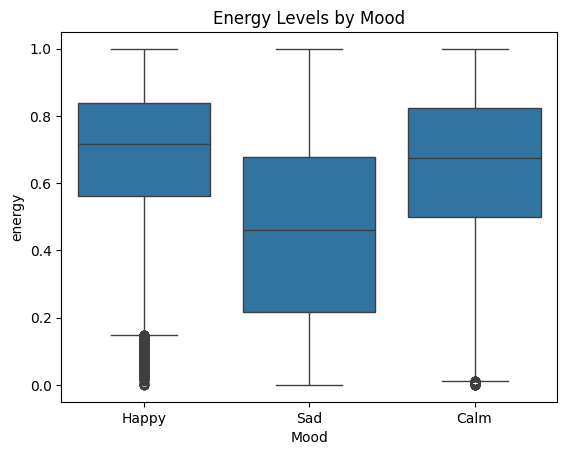

In [18]:
sns.boxplot(x='Mood', y='energy', data=df)
plt.title("Energy Levels by Mood")
plt.show()

# Top 10 Artists with Most Songs

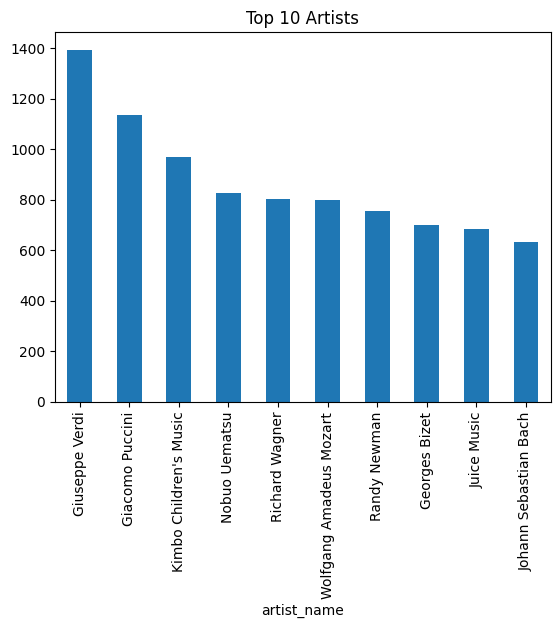

In [19]:
df['artist_name'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Artists")
plt.show()

# Correlation Heatmap

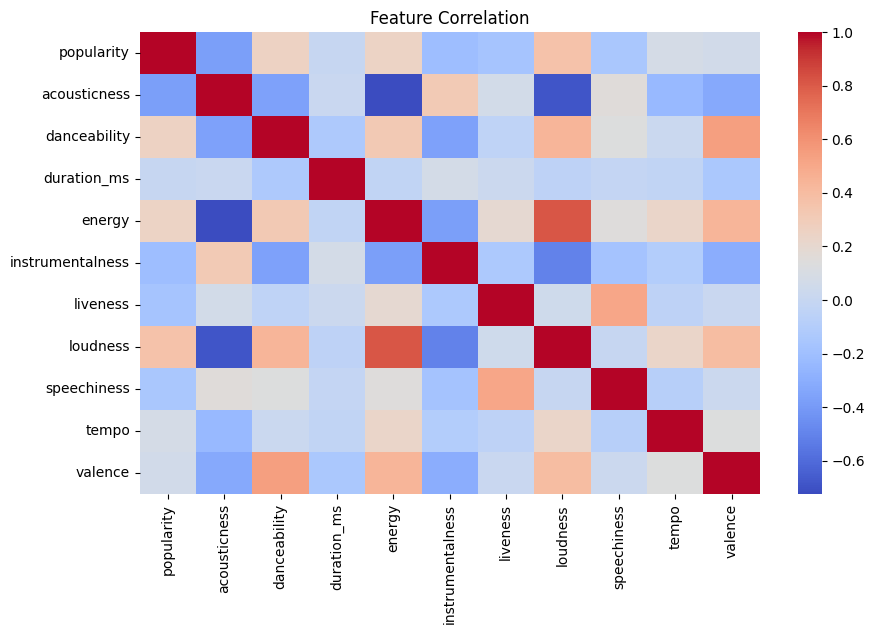

In [25]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [8]:
df.to_csv('MoodMusicData.csv', index=False)

## Key Findings

- Sad songs are the most common mood category in the dataset.
- Happy songs have the highest average danceability.
- Happy and Calm songs generally have higher energy levels than Sad songs.
- A small number of artists contribute a large number of tracks.
- Danceability and valence show a positive relationship.

## Conclusion

This project analyzed Spotify song features and classified tracks into Happy, Calm, and Sad moods using valence scores. The analysis revealed differences in danceability, energy, and artist contributions across mood categories. These insights can be useful for mood-based music recommendation systems.